In [1]:
import pandas as pd

# Load a snippet to inspect
trader_df = pd.read_csv('historical_data.csv', nrows=2)
sentiment_df = pd.read_csv('fear_greed_index.csv', nrows=2)

print("--- Trader Data Columns ---")
print(trader_df.columns)
print(trader_df.head(2))

print("\n--- Sentiment Data Columns ---")
print(sentiment_df.columns)
print(sentiment_df.head(2))

--- Trader Data Columns ---
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0           0  0xec09451986a1874e3a980418412fcd0201f500c95bac...  52017706630   
1           0  0xec09451986a1874e3a980418412fcd0201f500c95bac...  52017706630   

   Crossed       F

In [2]:
import pandas as pd

def load_and_merge_data(trader_path, sentiment_path):
    # 1. Load the datasets
    print("Loading datasets...")
    trader_df = pd.read_csv(trader_path)
    sentiment_df = pd.read_csv(sentiment_path)

    # 2. Clean up columns and string spaces if any
    trader_df.columns = trader_df.columns.str.strip()
    sentiment_df.columns = sentiment_df.columns.str.strip()

    # 3. Standardize dates to YYYY-MM-DD
    # Convert 'Timestamp IST' to datetime, then extract just the date
    trader_df['clean_date'] = pd.to_datetime(trader_df['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.strftime('%Y-%m-%Y')
    # Let's match the exact string format of the sentiment date
    trader_df['clean_date'] = pd.to_datetime(trader_df['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.date
    sentiment_df['clean_date'] = pd.to_datetime(sentiment_df['date']).dt.date

    # 4. Merge the datasets on our new 'clean_date' column
    print("Merging data on standardized date...")
    merged_df = pd.merge(trader_df, sentiment_df, on='clean_date', how='inner')

    print(f"Merge complete! Total rows in joined dataset: {len(merged_df)}")
    return merged_df

# Run the merge
# Replace with your actual file names/paths
merged_data = load_and_merge_data('historical_data.csv', 'fear_greed_index.csv')
print(merged_data[['Account', 'clean_date', 'Closed PnL', 'value', 'classification']].head())

Loading datasets...
Merging data on standardized date...
Merge complete! Total rows in joined dataset: 211218
                                      Account  clean_date  Closed PnL  value  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  2024-12-02         0.0     80   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  2024-12-02         0.0     80   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  2024-12-02         0.0     80   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  2024-12-02         0.0     80   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  2024-12-02         0.0     80   

  classification  
0  Extreme Greed  
1  Extreme Greed  
2  Extreme Greed  
3  Extreme Greed  
4  Extreme Greed  


In [3]:
# Ensure Closed PnL is numeric
merged_data['Closed PnL'] = pd.to_numeric(merged_data['Closed PnL'], errors='coerce')

# Define a profitable trade vs an unprofitable trade
# Note: Realized PnL of 0 usually means opening a position, filtering out 0 might give cleaner metrics for closed trades
completed_trades = merged_data[merged_data['Closed PnL'] != 0].copy()
completed_trades['is_profitable'] = completed_trades['Closed PnL'] > 0

# 1. Basic Sentiment Performance Aggregation
sentiment_analysis = completed_trades.groupby('classification').agg(
    total_trades=('Closed PnL', 'count'),
    win_rate=('is_profitable', 'mean'),
    total_pnl=('Closed PnL', 'sum'),
    avg_pnl=('Closed PnL', 'mean'),
    avg_size_usd=('Size USD', 'mean')
).reset_index()

print("\n=== PERFORMANCE BY SENTIMENT CLASSIFICATION ===")
print(sentiment_analysis)


=== PERFORMANCE BY SENTIMENT CLASSIFICATION ===
  classification  total_trades  win_rate     total_pnl     avg_pnl  \
0   Extreme Fear         10406  0.762156  7.391102e+05   71.027316   
1  Extreme Greed         20853  0.891670  2.715171e+06  130.205309   
2           Fear         29808  0.872886  3.357155e+06  112.625988   
3          Greed         25176  0.768907  2.150129e+06   85.403927   
4        Neutral         18159  0.823889  1.292921e+06   71.199993   

   avg_size_usd  
0   5467.570419  
1   2779.563632  
2   8041.140445  
3   5438.671764  
4   5556.444833  


In [4]:
# Group by sentiment AND side to see directional behavior
directional_analysis = completed_trades.groupby(['classification', 'Side']).agg(
    total_trades=('Closed PnL', 'count'),
    win_rate=('is_profitable', 'mean'),
    total_pnl=('Closed PnL', 'sum'),
    avg_pnl=('Closed PnL', 'mean')
).reset_index()

print("\n=== DIRECTIONAL BIAS ANALYSIS ===")
print(directional_analysis)


=== DIRECTIONAL BIAS ANALYSIS ===
  classification  Side  total_trades  win_rate     total_pnl     avg_pnl
0   Extreme Fear   BUY          3123  0.706052  3.730434e+05  119.450350
1   Extreme Fear  SELL          7283  0.786214  3.660668e+05   50.263189
2  Extreme Greed   BUY          6500  0.859538  1.883508e+05   28.977039
3  Extreme Greed  SELL         14353  0.906222  2.526821e+06  176.048252
4           Fear   BUY          9230  0.862514  1.935073e+06  209.650427
5           Fear  SELL         20578  0.877539  1.422082e+06   69.106910
6          Greed   BUY         11343  0.689147  6.144566e+05   54.170553
7          Greed  SELL         13833  0.834309  1.535673e+06  111.015159
8        Neutral   BUY          5861  0.776830  5.544151e+05   94.593942
9        Neutral  SELL         12298  0.846316  7.385056e+05   60.050869


C:\Users\Dell-07\AppData\Local\Temp\ipykernel_18212\1284229342.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Saved Plot 1: total_pnl_by_sentiment.png


C:\Users\Dell-07\AppData\Local\Temp\ipykernel_18212\1284229342.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Saved Plot 2: position_sizing_distribution.png


<Figure size 1200x500 with 0 Axes>

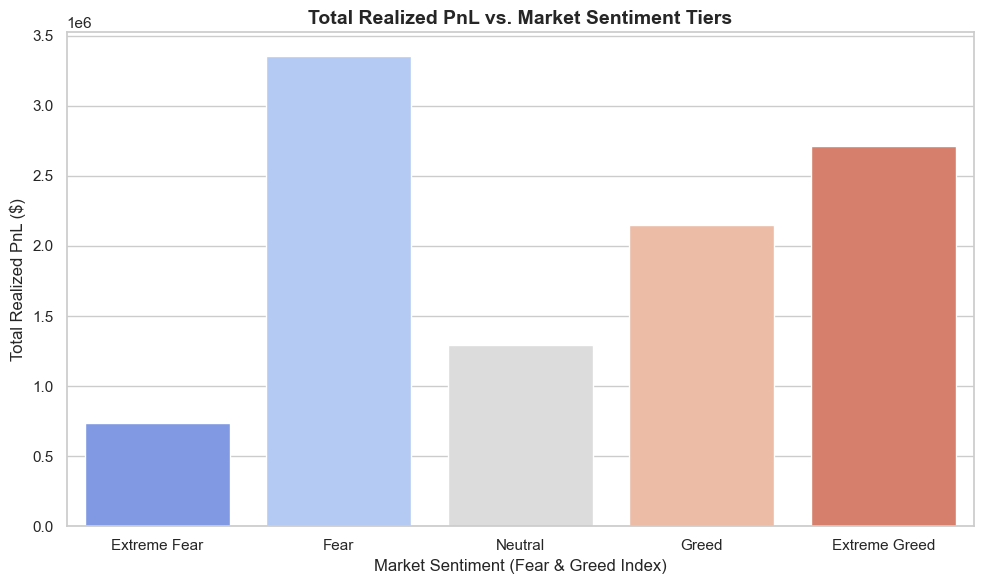

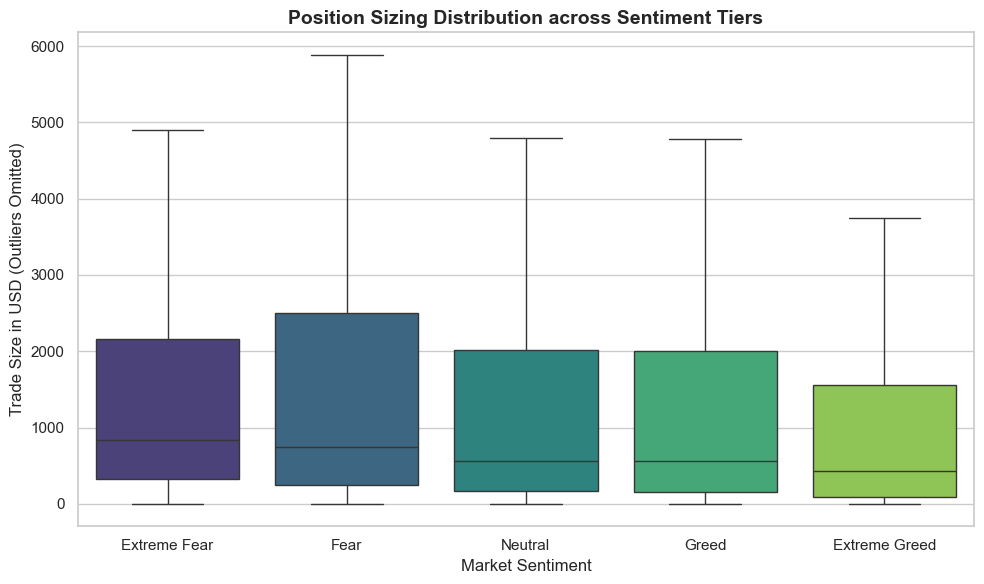

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for professional look
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# Plot 1: Win Rate and Average PnL by Sentiment
fig, ax1 = plt.subplots(figsize=(10, 6))

# Sort classifications logically for the X-axis
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

# Bar plot for Total PnL
sns.barplot(
    data=sentiment_analysis,
    x='classification',
    y='total_pnl',
    order=sentiment_order,
    palette='coolwarm',
    ax=ax1
)
ax1.set_title('Total Realized PnL vs. Market Sentiment Tiers', fontsize=14, fontweight='bold')
ax1.set_xlabel('Market Sentiment (Fear & Greed Index)', fontsize=12)
ax1.set_ylabel('Total Realized PnL ($)', fontsize=12)

plt.tight_layout()
plt.savefig('total_pnl_by_sentiment.png', dpi=300)
print("Saved Plot 1: total_pnl_by_sentiment.png")

# Plot 2: Position Sizing Behavior
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=completed_trades,
    x='classification',
    y='Size USD',
    order=sentiment_order,
    palette='viridis',
    showfliers=False # Removes massive outliers to make the chart readable
)
plt.title('Position Sizing Distribution across Sentiment Tiers', fontsize=14, fontweight='bold')
plt.xlabel('Market Sentiment', fontsize=12)
plt.ylabel('Trade Size in USD (Outliers Omitted)', fontsize=12)

plt.tight_layout()
plt.savefig('position_sizing_distribution.png', dpi=300)
print("Saved Plot 2: position_sizing_distribution.png")